# T09 — ARMA Model — Book: CH06

**Methodology**: Marco Peixeiro, *Time Series Forecasting in Python*, Chapter 6.

### Book-mandated steps:
1. ADF stationarity test → confirm d=0
2. ACF + PACF plots
3. `optimize_ARMA` → select by lowest AIC (SARIMAX)
4. Fit best model → Ljung-Box residuals
5. `rolling_forecast_engine` → walk-forward validation
6. Full test evaluation

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial

# Book imports — exactly as CH05 uses them
from statsmodels.tsa.statespace.sarimax import SARIMAX


from src.models.classical import (
    load_and_prepare,
    run_stationarity_report,
    select_best_arma_order, _get_representative_engine,
    check_residuals, rolling_forecast_engine,
    predict_rul_arima_with_ci, predict_dataset_with_ci, 
     validate_model_rolling,
)
from src.evaluation.metrics import evaluate

PROC_DIR    = ROOT / "data" / "processed"
RAW_PATH    = str(ROOT / "data" / "raw" / "train_FD004.txt")
# 16 sensors retained after T04 variance filter (dropped s1, s5, s16, s18, s19)
SENSOR_COLS = [f"s{i}" for i in [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 20, 21]]

## 1. Load data + build health_index

In [3]:
train, test, THRESHOLD = load_and_prepare(PROC_DIR, SENSOR_COLS)

Loaded: train=(61249, 123), test=(41214, 123)
Engines: train=249, test=248
  Degradation-correlation filter (|r| ≥ 0.5):
    Kept    9 sensors: ['s2', 's3', 's4', 's8', 's9', 's11', 's13', 's14', 's17']
    Dropped  7 sensors: ['s6', 's7', 's10', 's12', 's15', 's20', 's21']
  PCA fit on 61249 rows, 9 sensors (|r|≥0.5)
  PC1 explains 76.3% of within-condition variance  (using 9/16 sensors, |r|≥0.5)
  RUL regressor (all data): RUL = -5.19 * hi + 0.00  (R²=-5.189)
  RUL regressor (recent 60%): RUL = -29.69 * hi + 82.68  (R2=0.651)

Failure threshold (q=0.05): 1.4117
Health index range: [-1.531, 6.471]


## 2. Stationarity check — ADF (CH06)

ARMA requires stationary series (d=0). ADF on health_index confirms this.

In [4]:
# Stratified ADF across all 4 subsets
stationarity_df = run_stationarity_report(train, n_engines=10)
# ARMA requires d=0 — confirm here


Stationarity Report (ADF test per sampled engine):
engine_id   level_p     diff1_p     rec_d
--------------------------------------------
1           0.9991      0.9931      2.0
2           1.0         0.7229      2.0
3           1.0         0.4577      2.0
4           1.0         0.1697      2.0
5           1.0         0.9941      2.0
6           1.0         0.9811      2.0
7           0.9968      0.0         1.0
8           1.0         0.903       2.0
9           1.0         0.4393      2.0
10          1.0         0.8217      2.0

d distribution: {2: 9, 1: 1}
→ recommended d = 2  (modal across 10 sampled engines)


In [5]:
d_counts = stationarity_df["recommended_d"].value_counts().sort_index()
print(d_counts.to_string())
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\n→ MODAL_D = {MODAL_D}")

recommended_d
1    1
2    9

→ MODAL_D = 2


## 3. ACF and PACF plots (CH06)

ACF tail-off + PACF tail-off = ARMA(p,q) signature.

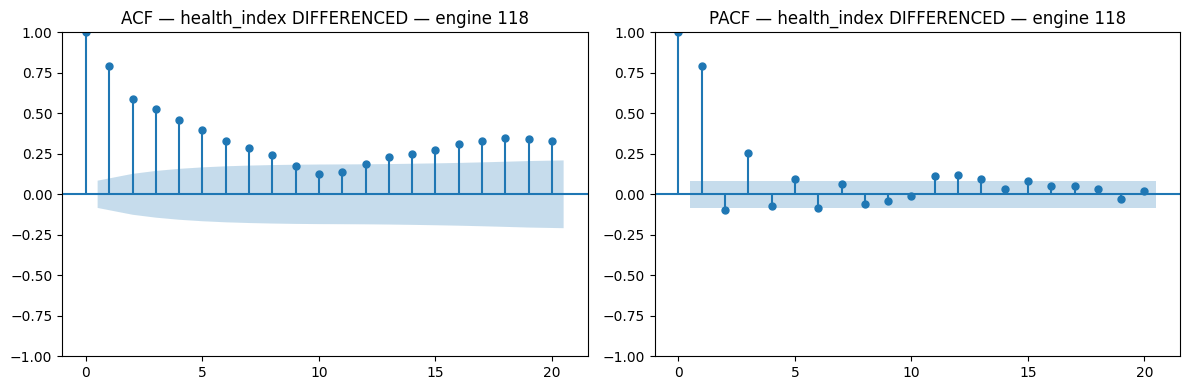

ACF tail-off + PACF tail-off => ARMA(p,q) model


In [6]:
rep_eid, rep_smth = _get_representative_engine(train)
smth_diff = np.diff(rep_smth, n=1)
from src.models.classical import plot_acf_pacf
plot_acf_pacf(smth_diff, lags=20, title=f"health_index DIFFERENCED — engine {rep_eid}")
print("ACF tail-off + PACF tail-off => ARMA(p,q) model")

## 4. `optimize_ARMA` — select (p,q) by AIC (CH06 core step)

Book sorts all (p,q) combos by AIC ascending. Lowest AIC wins.

In [7]:
BEST_P, BEST_Q = select_best_arma_order(train, d=MODAL_D, n_engines=15)

  engine 1: best (p,q)=(3, 1)  (AIC=-1752.22)
  engine 2: best (p,q)=(1, 2)  (AIC=-1844.03)
  engine 3: best (p,q)=(3, 2)  (AIC=-1800.73)
  engine 4: best (p,q)=(2, 2)  (AIC=-1419.12)
  engine 5: best (p,q)=(1, 2)  (AIC=-1056.36)
  engine 6: best (p,q)=(3, 3)  (AIC=-1809.87)
  engine 7: best (p,q)=(2, 1)  (AIC=-1242.4)
  engine 8: best (p,q)=(3, 2)  (AIC=-1350.05)
  engine 9: best (p,q)=(2, 1)  (AIC=-1875.99)
  engine 10: best (p,q)=(2, 3)  (AIC=-1771.21)
  engine 11: best (p,q)=(2, 1)  (AIC=-1834.98)
  engine 12: best (p,q)=(2, 2)  (AIC=-1179.06)
  engine 13: best (p,q)=(1, 1)  (AIC=-1426.8)
  engine 14: best (p,q)=(2, 3)  (AIC=-1367.57)
  engine 15: best (p,q)=(2, 2)  (AIC=-1175.24)

→ Modal best ARMA order: (2,2)  (from 15 engines, freq=[((2, 2), 3), ((2, 1), 3), ((1, 2), 2), ((3, 2), 2), ((2, 3), 2)])


## 5. Fit best ARMA + Ljung-Box (CH06 requirement)

In [8]:
rep_eid, rep_smth = _get_representative_engine(train)
# WHY: SARIMAX(p, d, q) — SARIMAX handles d internally so forecast preserves trend
from src.models.classical import RECENT_WINDOW
fit_series = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
model_fit = SARIMAX(fit_series, order=(BEST_P, MODAL_D, BEST_Q),
                    simple_differencing=False).fit(disp=False)
print(model_fit.summary())
lb_result = check_residuals(model_fit.resid, model_name=f"ARMA({BEST_P},{BEST_Q})")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   50
Model:               SARIMAX(2, 2, 2)   Log Likelihood                 122.577
Date:                Sat, 02 May 2026   AIC                           -235.155
Time:                        18:28:10   BIC                           -225.799
Sample:                             0   HQIC                          -231.619
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1100      0.266      0.414      0.679      -0.411       0.631
ar.L2          0.1495      0.203      0.738      0.461      -0.248       0.547
ma.L1          0.0311      0.492      0.063      0.9

## 6. Rolling forecast — walk-forward validation (CH06 pattern)

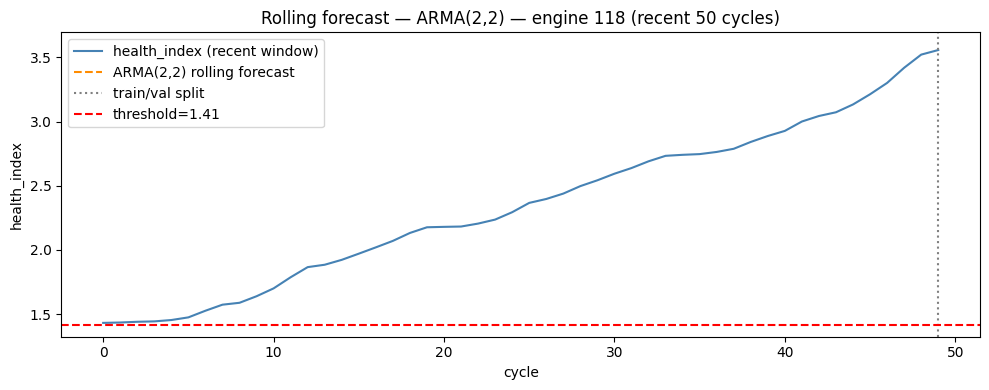

Rolling forecast RMSE: 0.0301


In [9]:
rep_eid, rep_smth = _get_representative_engine(train)
TRAIN_LEN = int(len(rep_smth) * 0.7)
WINDOW    = 1

# WHY: SARIMAX(p, d, q) on original smoothed series (trend-preserving ARMA)
from src.models.classical import RECENT_WINDOW
fit_series     = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
diff_train_len = min(TRAIN_LEN, len(fit_series) - 1)

pred_arma = rolling_forecast_engine(
    series=fit_series, train_len=diff_train_len,
    order=(BEST_P, MODAL_D, BEST_Q),
    window=WINDOW,
)

actual_val = fit_series[diff_train_len: diff_train_len + len(pred_arma)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fit_series, color="steelblue", label="health_index (recent window)")
ax.plot(range(diff_train_len, diff_train_len + len(pred_arma)), pred_arma,
        color="darkorange", ls="--", label=f"ARMA({BEST_P},{BEST_Q}) rolling forecast")
ax.axvline(diff_train_len, color="gray", ls=":", label="train/val split")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.set_title(f"Rolling forecast — ARMA({BEST_P},{BEST_Q}) — engine {rep_eid} (recent {RECENT_WINDOW} cycles)")
ax.legend(); plt.tight_layout(); plt.show()

rmse_roll = float(np.sqrt(np.mean((actual_val - pred_arma)**2)))
print(f"Rolling forecast RMSE: {rmse_roll:.4f}")

## 7. Full test-set evaluation

In [10]:
from functools import partial
# NOTE: ARMA with d>0 is ARIMA internally — labelled correctly as ARIMA
predict_fn = partial(predict_rul_arima_with_ci, p=BEST_P, d=MODAL_D, q=BEST_Q)
y_true, y_pred, y_lower, y_upper, engine_ids = predict_dataset_with_ci(
    test, predict_fn, THRESHOLD, verbose_engines=True
)
evaluate(y_true, y_pred, model_name=f"ARIMA({BEST_P},{MODAL_D},{BEST_Q})")


  engine    1  true=  22.0  pred=  21.0  [ 15.0,  44.0]  err=-1.0
  engine    2  true=  39.0  pred=  12.0  [  8.0,  63.2]  err=-27.0
  engine    3  true= 107.0  pred= 109.9  [109.9, 109.9]  err=+2.9
  engine    4  true=  75.0  pred= 110.6  [ 97.0, 110.6]  err=+35.6
  engine    5  true= 125.0  pred=  79.1  [ 43.0,  79.1]  err=-45.9
  engine    6  true=  78.0  pred= 109.2  [ 99.0, 109.2]  err=+31.2
  engine    7  true=  94.0  pred= 121.0  [ 44.0, 125.0]  err=+27.0
  engine    8  true=  14.0  pred=   0.0  [  0.0,   0.0]  err=-14.0
  engine    9  true=  99.0  pred= 108.0  [ 56.0, 108.0]  err=+9.0
  engine   10  true= 125.0  pred= 111.7  [111.7, 111.7]  err=-13.3
  engine   11  true= 125.0  pred= 125.0  [ 47.0, 125.0]  err=+0.0
  engine   12  true=   7.0  pred=   0.0  [  0.0,   0.0]  err=-7.0
  engine   13  true=  71.0  pred= 125.0  [ 96.0, 125.0]  err=+54.0
  engine   14  true= 105.0  pred=  98.3  [ 63.0,  98.3]  err=-6.7
  engine   15  true=  12.0  pred=   3.0  [  3.0,   3.0]  err=-9.0
  

{'rmse': 30.46764373779297,
 'nasa_score': 20982.8203125,
 'nasa_score_mean': 84.60814642137096,
 'r2_score': 0.4975166916847229,
 'bias': -3.996279239654541}

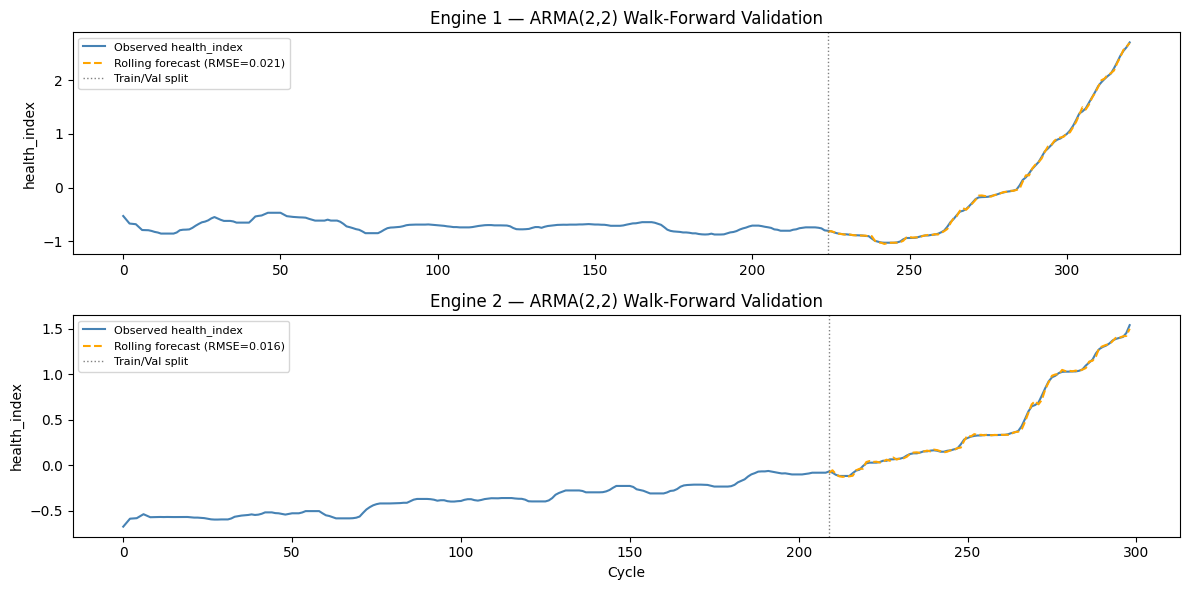


ARMA(2,2) Walk-Forward Validation Summary
Engines validated : 2
Mean RMSE         : 0.0185
Std RMSE          : 0.0024
Best engine RMSE  : 0.0161
Worst engine RMSE : 0.0209


In [11]:
val_rmse = validate_model_rolling(
    train      = train,
    order      = (BEST_P, MODAL_D, BEST_Q),
    n_engines  = 2,
    model_name = f"ARMA({BEST_P},{BEST_Q})"
)

In [12]:
from src.evaluation.metrics import save_model_results
save_model_results(
    model_name = f"ARIMA({BEST_P},{MODAL_D},{BEST_Q})",
    model_type = "classical",
    y_true     = y_true,
    y_pred     = y_pred,
    y_lower    = y_lower,
    y_upper    = y_upper,
)


  [ARIMA(2,2,2)] RMSE: 30.4676  |  NASA Score: 20982.82 (mean: 84.61)  |  R2: 0.4975  |  Bias: -4.00 (early ↓)
  → Saved to results/all_model_results.csv


{'rmse': 30.46764373779297,
 'nasa_score': 20982.8203125,
 'nasa_score_mean': 84.60814642137096,
 'r2_score': 0.4975166916847229,
 'bias': -3.996279239654541}

In [13]:
from src.evaluation.metrics import save_predictions_csv

save_predictions_csv(
    engine_ids = engine_ids,
    y_true     = y_true,
    y_pred     = y_pred,
    y_lower    = y_lower,
    y_upper    = y_upper,
    model_name = f"ARIMA({BEST_P},{MODAL_D},{BEST_Q})",
)



  [ARIMA(2,2,2)] Bound Validation Report (248 engines):
    ✓ negative_preds: 0
    ✓ over_cap_preds: 0
    ✓ inverted_bounds: 0
    ✓ pred_outside_interval: 0
    ✓ nan_or_inf: 0
    → All checks passed — predictions are numerically valid.
  → Saved 248 predictions to results/predictions/ARIMA2_2_2.csv
     Coverage: 52.0%  |  Avg interval width: 42.69 cycles


PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/predictions/ARIMA2_2_2.csv')